<a href="https://colab.research.google.com/github/rubenchov/aprendizajeautomaticovision/blob/main/IntroML_4_IrisLineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importar librerías

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import random

from sklearn.datasets import load_iris #Conjunto de datos Iris
from sklearn.model_selection import train_test_split #Para partición del conjunto de datos en entrenamiento y prueba
from sklearn.linear_model import LinearRegression #Modelo de regresión lineal
from sklearn.preprocessing import LabelEncoder #Para convertir etiquetas
from sklearn.metrics import mean_absolute_error, mean_squared_error #Para validación con cálculo de errores en predicciones
from sklearn.metrics import ConfusionMatrixDisplay #Matriz de confusión (para validación)

Cargar conjunto de datos

In [ ]:
#Cargar conjunto de datos
iris = load_iris()

#Convertir a pandas (dataframe - df)
iris_features = pd.DataFrame(data=iris.data, columns=iris.feature_names) #Características X

Definir entradas como matriz X

In [ ]:
X = iris_features.copy()
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Codificar variables categóricas (nombres de especies) en variables numéricas (0, 1 o 2)

In [ ]:
le = LabelEncoder()
encod = le.fit_transform(iris.target_names)
print(encod)

[0 1 2]


Decodificar (verificar de númericas a categóricas)

In [ ]:
print('Clase 0: ', le.inverse_transform([0]))
print('Clase 1: ', le.inverse_transform([1]))
print('Clase 2: ', le.inverse_transform([2]))

Clase 0:  ['setosa']
Clase 1:  ['versicolor']
Clase 2:  ['virginica']


Partir el conjunto de datos en entrenamiento (66%) y validación (33%)

El parámetro "random_state" sirve para controlar la aleatoriedad y siempre, aunque aleatoria, hacer la partición de la misma manera, lo cual es útil para hacer la partición en diferentes simulaciones y con diferentes modelos con la misma partición.

In [ ]:
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.33, random_state=101)
print('X_train: ', X_train.shape)
print('X_test: ', X_test.shape)
print('y_train: ', y_train.shape)
print('y_test: ', y_test.shape)

X_train:  (100, 4)
X_test:  (50, 4)
y_train:  (100,)
y_test:  (50,)


Modelo

In [ ]:
lr = LinearRegression() #Se define modelo lineal sin configurar ningún hiperparámetro
lr.fit(X_train, y_train) #Se entrena el modelo con el subconjunto "train"

LinearRegression()

Se realizan predicciones sobre el subconjunto de validación (test) que no participó durante el entrenamiento.

In [ ]:
pred = lr.predict(X_test)
print(pred)

[-1.85950176e-01 -2.48534714e-02  2.41439307e-01  1.53265436e+00
  1.19852769e+00  1.62087317e+00  1.40689962e+00  1.22930606e+00
  1.72876621e+00 -6.65711701e-03  1.76187985e+00 -2.01822616e-01
  6.39317497e-02  1.94496687e+00  1.60502777e+00  1.14215057e+00
  1.16280604e+00  1.18271717e+00 -4.25208012e-03  1.49435271e+00
  1.04592415e+00 -9.79953020e-02  1.19755726e+00  1.18199987e+00
  1.15870935e+00  1.08666180e+00  9.42275720e-01  2.09965377e+00
  1.98417482e-02  1.53582199e-01  2.00401688e+00  1.20770327e+00
  1.67624497e+00  1.07497205e+00  1.85811020e+00  1.24568595e+00
  1.30306839e+00  1.29315926e+00  1.21259935e+00  2.02573271e+00
  5.63657407e-02 -1.16183816e-01  2.30771324e-02  1.50383942e+00
  1.37016482e+00 -7.80492902e-02  1.90282854e+00  9.71948048e-01
 -6.93824812e-05  9.29127292e-01]


Se muestran resultados continuos, cuando en realidad las clases son discretas (0, 1 o 2)

Validar

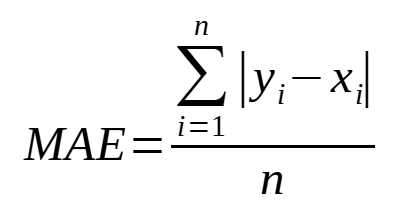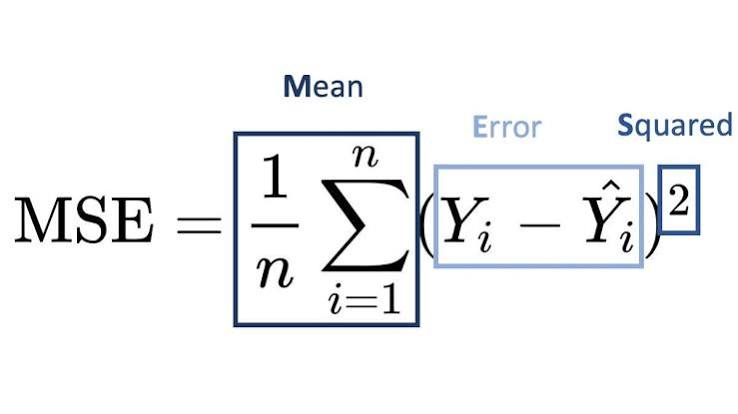

In [ ]:
print('MAE:', mean_absolute_error(y_test, pred))
print('MSE:', mean_squared_error(y_test, pred))

MAE: 0.17277741710382924
MSE: 0.04848276133335731


Predecir en un solo elemento aleatorio del conjunto de datos (subconjunto de prueba)

Extraer un solo elemento

In [ ]:
single_item_index = random.randint(0, len(X_test))
single_item = X_test.iloc[[single_item_index]]
print(single_item)

    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
89                5.5               2.5                4.0               1.3


Ingresar este elemento extraído al modelo

In [ ]:
single_prediction = lr.predict(single_item)
print('Predicted Value:', single_prediction[0])

Predicted Value: 1.207703270288763


Extract class using inverse label encoder

In [ ]:
decoded_prediction = le.inverse_transform([int(round(single_prediction[0]))]) #Redondear, convertir a entero y decodificar la predicción
decoded_actual = le.inverse_transform([y_test[single_item_index]]) #Redondear, convertir a entero y decodificar la real del subconjunto de prueba para verificar

print('Especie predicha: ', decoded_prediction[0])
print('Especie real: ', decoded_actual[0])

Especie predicha:  versicolor
Especie real:  versicolor


Comparación de resultados

In [ ]:
if decoded_prediction[0] == decoded_actual[0]:
    print("La predicción es CORRECTA")
else:
    print("La predicción es INCORRECTA")

La predicción es CORRECTA


Más análisis, prediciendo todas las que están en el subconjunto de prueba y comparando.

In [ ]:
pred_labels = le.inverse_transform(np.round(pred).astype(int))
actual_labels = le.inverse_transform(y_test)
results = np.array([pred_labels, actual_labels])
results_df = pd.DataFrame(results.T, columns=['Predicted (linear regression)', 'Actual (Ground-Truth)'])
print(results_df)

   Predicted (linear regression) Actual (Ground-Truth)
0                         setosa                setosa
1                         setosa                setosa
2                         setosa                setosa
3                      virginica             virginica
4                     versicolor            versicolor
5                      virginica             virginica
6                     versicolor            versicolor
7                     versicolor            versicolor
8                      virginica             virginica
9                         setosa                setosa
10                     virginica             virginica
11                        setosa                setosa
12                        setosa                setosa
13                     virginica             virginica
14                     virginica             virginica
15                    versicolor            versicolor
16                    versicolor            versicolor
17        

Contando el error manualmente

In [ ]:
cont = 0
for i in range(len(pred)):
  if int(round(pred[i])) != y_test[i]:
    cont+=1
print('Count errors: ', cont)
print("Error rate: ", cont/len(pred))

Count errors:  2
Error rate:  0.04


Calculando la exactitud con librería Scikit Learn

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, pred.round())
print("Accuracy:", accuracy)

Accuracy: 0.96


Análisis con matriz de confusión

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = pred.round() #Redondear para eliminar decimales de la predicción
confusion_matrix(y_test, y_pred) #Obtener la matriz de confusión

array([[15,  0,  0],
       [ 0, 21,  1],
       [ 0,  1, 12]])

Se evidencia una diagonal con valores altos, que indica las buenas predicciones.

Obtención de la matriz de confusión de forma gráfica

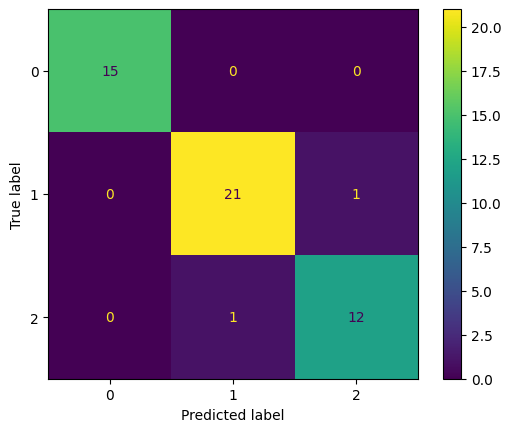

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)